In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


100%|███████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 2.68MB/s]
100%|███████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 96.1kB/s]
100%|███████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.01MB/s]
100%|███████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


Train samples: 60000
Test  samples: 10000


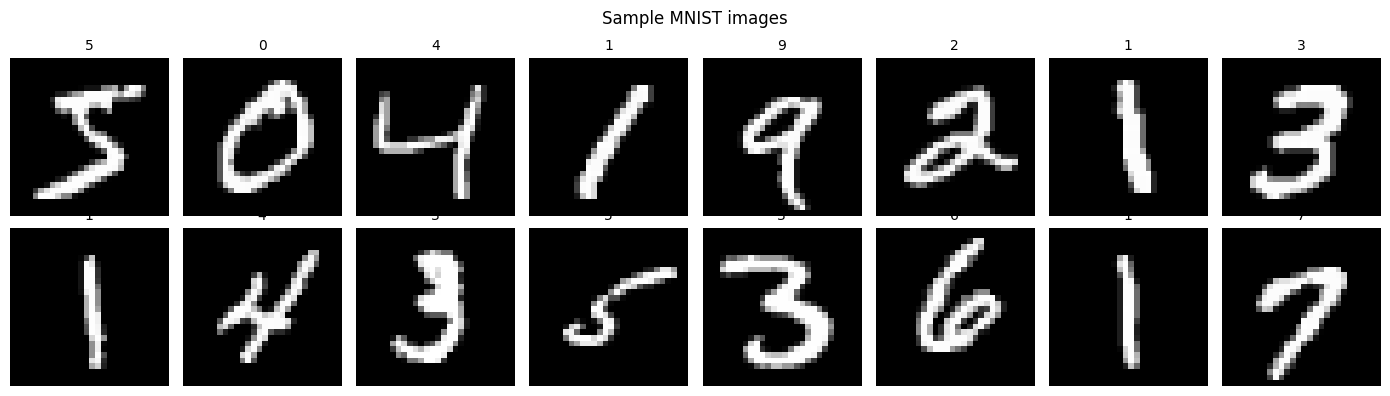

In [2]:
# ── 1. Load MNIST with transforms ─────────────────
transform = transforms.Compose([
    transforms.ToTensor(),                        # PIL → tensor [0,1]
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST mean & std
])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f"Train samples: {len(train_ds)}")
print(f"Test  samples: {len(test_ds)}")

# Visualize sample images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_ds[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')
plt.suptitle('Sample MNIST images', fontsize=12)
plt.tight_layout()
plt.show()


In [3]:
# ── 2. CNN Model ──────────────────────────────────
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 1×28×28 → 32×28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → 32×14×14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → 64×14×14
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → 64×7×7
            nn.Dropout2d(0.25)
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),                                 # → 3136
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)                           # 10 digit classes
        )

    def forward(self, x):
        return self.classifier(self.features(x))
model = CNN().to(device)
print("\n── Model ──")
print(model)
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")



── Model ──
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters: 421,642


In [4]:
# ── 3. Training setup ─────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)

In [5]:
# ── 4. Train & evaluate functions ─────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X)
        correct    += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out   = model(X)
            loss  = criterion(out, y)
            total_loss += loss.item() * len(X)
            correct    += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [6]:
# ── 5. Training loop ──────────────────────────────
EPOCHS = 5
history = {'train_loss':[], 'test_loss':[], 'train_acc':[], 'test_acc':[]}
best_acc, best_loss = 0, float('inf')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(model,    test_loader,  criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['test_loss'].append(te_loss)
    history['train_acc'].append(tr_acc)
    history['test_acc'].append(te_acc)

    if te_acc > best_acc:
        best_acc  = te_acc
        best_loss = te_loss
        torch.save(model.state_dict(), 'best_cnn.pth')

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Test  Loss: {te_loss:.4f} Acc: {te_acc:.4f}")

print(f"\nBest Test Accuracy: {best_acc:.4f}")

Epoch 1/5 | Train Loss: 0.2281 Acc: 0.9308 | Test  Loss: 0.0446 Acc: 0.9847
Epoch 2/5 | Train Loss: 0.0887 Acc: 0.9742 | Test  Loss: 0.0329 Acc: 0.9885
Epoch 3/5 | Train Loss: 0.0686 Acc: 0.9794 | Test  Loss: 0.0298 Acc: 0.9891
Epoch 4/5 | Train Loss: 0.0501 Acc: 0.9848 | Test  Loss: 0.0224 Acc: 0.9931
Epoch 5/5 | Train Loss: 0.0431 Acc: 0.9867 | Test  Loss: 0.0242 Acc: 0.9928

Best Test Accuracy: 0.9931


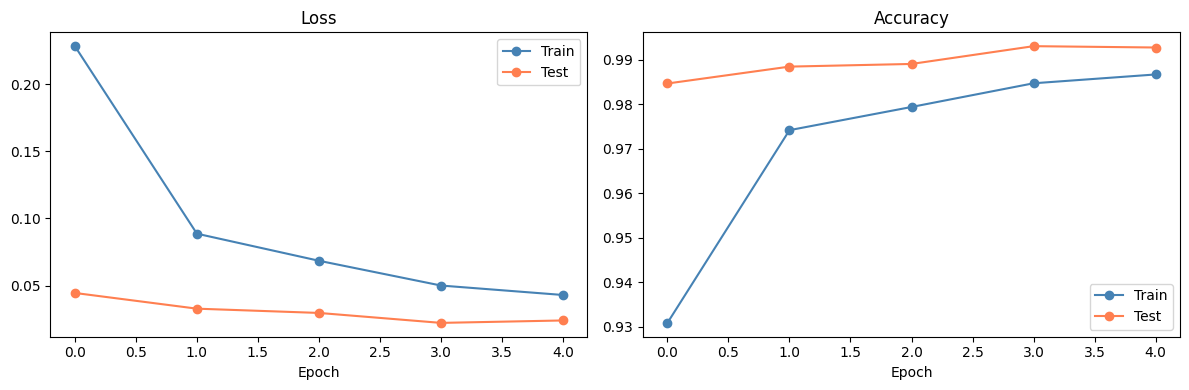

In [7]:
# ── 6. Plot curves ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], 'o-', label='Train', color='steelblue')
axes[0].plot(history['test_loss'],  'o-', label='Test',  color='coral')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], 'o-', label='Train', color='steelblue')
axes[1].plot(history['test_acc'],  'o-', label='Test',  color='coral')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()


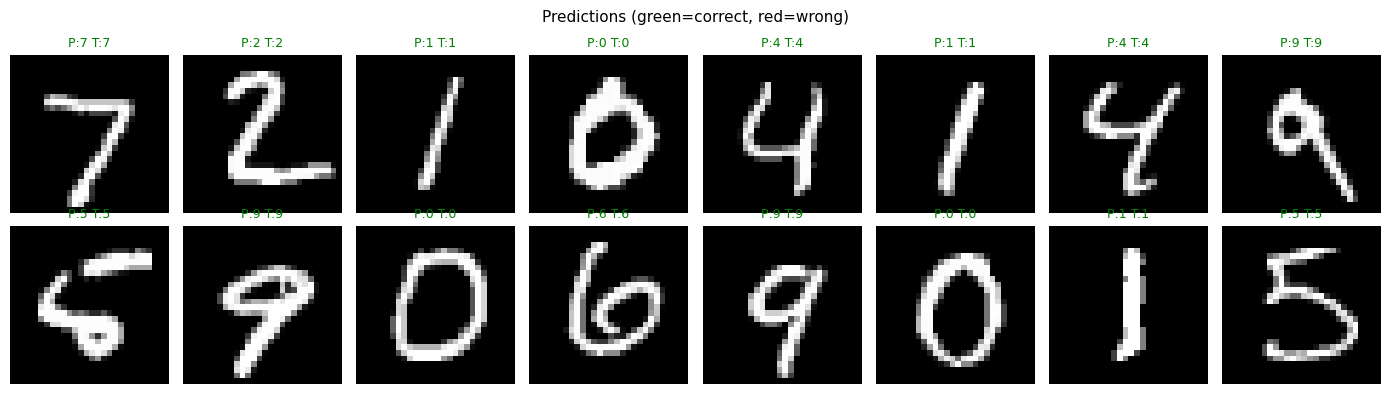

In [9]:
# ── 7. Visualize predictions ──────────────────────
model.load_state_dict(torch.load('best_cnn.pth', weights_only=True))
model.eval()

images, labels = next(iter(test_loader))
images, labels = images[:16].to(device), labels[:16].to(device)

with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze()
    ax.imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f"P:{preds[i].item()} T:{labels[i].item()}",
                 color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=11)
plt.tight_layout()
plt.show()